In [1]:
import numpy as np
import pyccl as ccl
from astropy.io import fits
import matplotlib.pyplot as plt

dataset = "/home/weichen/cosmo_practice/dataset_hsc_y3.fits"
with fits.open(dataset) as hd:
    ds_t, wp_t  = hd['ds'].data, hd['wp'].data
    xip_t, xim_t = hd['xip'].data, hd['xim'].data
    full_cov = hd['COVMAT'].data
    z_s, nz_s = hd['nz_source'].data['Z_MID'], hd['nz_source'].data['BIN1']
    nzl = hd['nz_lens'].data
    z_lg = nzl['Z_MID']
    nz_l = [nzl['BIN1'], nzl['BIN2'], nzl['BIN3']]   # LOWZ, CMASS1, CMASS2 的 p_l(z)

    print(repr(hd['ds'].header))
    print(hd['ds'].columns)

alpha_mag = [2.259, 3.563, 3.729]   # Table I 的 prior 中心值
SIGC_CONST = 1.6624e18              # c²/(4πG) [M⊙/Mpc], Eq.(8) 的常數
ds_rmax = {1: 30.0, 2: 40.0, 3: 80.0}

ds_cut = np.zeros(len(ds_t), dtype=bool)
for _b, _rmax in ds_rmax.items():
    ds_cut |= (ds_t['BIN1'] == _b) & (ds_t['ANG'] >= 12.0) & (ds_t['ANG'] <= _rmax)

wp_cut  = (wp_t['ANG'] >= 8.0)  & (wp_t['ANG'] <= 80.0)
xip_cut = (xip_t['ANG'] >= 7.9)  & (xip_t['ANG'] <= 50.1)
xim_cut = (xim_t['ANG'] >= 31.6) & (xim_t['ANG'] <= 158.0)

n_ds_full, n_xip_full, n_xim_full, n_wp_full = len(ds_t), len(xip_t), len(xim_t), len(wp_t)
off_xip = n_ds_full
off_xim = n_ds_full + n_xip_full
off_wp  = n_ds_full + n_xip_full + n_xim_full   # 全長

keep = np.concatenate([np.where(ds_cut)[0],
                       np.where(xip_cut)[0] + off_xip,
                       np.where(xim_cut)[0] + off_xim,
                       np.where(wp_cut)[0]  + off_wp])

cov = full_cov[np.ix_(keep, keep)]
icov = np.linalg.inv(cov) * (107*13 - 74 - 2) / (107*13 - 1)   # Hartlap
err = np.sqrt(np.diag(cov))   # error bar

data_vec = np.concatenate([ds_t['VALUE'][ds_cut], xip_t['VALUE'][xip_cut],
                           xim_t['VALUE'][xim_cut], wp_t['VALUE'][wp_cut]])

n_ds, n_xip, n_xim, n_wp = ds_cut.sum(), xip_cut.sum(), xim_cut.sum(), wp_cut.sum()

print(f"data vector: ds={n_ds}, xip={n_xip}, xim={n_xim}, wp={n_wp}, total={len(data_vec)}")

z_l_eff = [0.2607, 0.5106, 0.6264]

'''
Sec. III D data vector
ΔΣ: R=12-30/40/80
wp: 8-80 h⁻¹Mpc
ξ₊: 7.9-50.1′   ξ₋ 31.6-158′
'''

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   56 / length of dimension 1                          
NAXIS2  =                   90 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    7 / number of table fields                         
2PTDATA =                    T                                                  
EXTNAME = 'ds      '                                                            
QUANT1  = 'GPR     '                                                            
QUANT2  = 'G+R     '                                                            
KERNEL_1= 'nz_lens '        

'\nSec. III D data vector\nΔΣ: R=12-30/40/80\nwp: 8-80 h⁻¹Mpc\nξ₊: 7.9-50.1′   ξ₋ 31.6-158′\n'

In [2]:
om_m_ref = 0.279
C_OVER_H0   = 2997.92458

def E_flat(z, Om):
    return np.sqrt(Om*(1.0+z)**3 + (1.0-Om))

def chi_hinv_flat(z, Om, n=512):
    zz = np.linspace(0.0, z, n)
    return C_OVER_H0 * np.trapezoid(1.0/E_flat(zz, Om), zz)

def sigcrit_inv_mean(zl, om, z_s, nz_s):
    """Source-n(z)-averaged comoving Sigma_crit^-1 (constants cancel in the ratio)."""
    Dl = chi_hinv_flat(zl, om)
    Ds = np.array([chi_hinv_flat(z, om) for z in z_s])
    integ = np.where(z_s > zl, Dl*(Ds - Dl)/np.where(Ds > 0, Ds, 1.0), 0.0) * nz_s
    return np.trapezoid(integ, z_s) / np.trapezoid(nz_s, z_s)

def theory_vector(cosmo, X, b, A_IA=0.0, dm=0.0, dzph=0.0, pi_max=100.0):
    h = cosmo['h']
    om = cosmo['Omega_c'] + cosmo['Omega_b']
    rho_m = ccl.rho_x(cosmo, 1.0, 'matter', is_comoving=True)
    m_ds, m_wp = [], []
    nz_true = np.interp(z_s + dzph, z_s, nz_s, left=0., right=0.)   # Eq.18

    for i in range(3):
        zl = z_l_eff[i]
        a_l = 1.0/(1.0+z_l_eff[i])
        
        # ===== 重標定因子( z_l 不同)=====
        E_C, E_ref = E_flat(zl, om), E_flat(zl, om_m_ref)
        chi_C, chi_ref = chi_hinv_flat(zl, om), chi_hinv_flat(zl, om_m_ref)

        # reference-cosmology lensing-efficiency ratio for dSigma (missing amplitude term)
        f_ds = (sigcrit_inv_mean(zl, om, z_s, nz_true) / sigcrit_inv_mean(zl, om_m_ref, z_s, nz_s)) 
        
        R_fac, E_fac = chi_C/chi_ref, E_C/E_ref
        # pimax_wp = pi_max
        pimax_wp = (E_ref/E_C)*pi_max
        '''
        for pi_max rescale, the larger R of wp:
        
        (E_ref/E_C)*100: ~0.96
        fix at 100: ~0.91-0.93
        
        '''
        
        print('R_fac, E_fac in ',i, ':', R_fac, E_fac)
        # ===============================
        
        rp_ds = ds_t['ANG'][(ds_t['BIN1']==i+1) & ds_cut]
        rp_wp = wp_t['ANG'][(wp_t['BIN1']==i+1) & wp_cut]
        rp_ds_true = R_fac * rp_ds
        rp_wp_true = R_fac * rp_wp

        # ============ ΔΣ_mag:Eq.(4) ============
        # --- Σc(Eq. 8, comoving)---
        kern_Mpc = sigcrit_inv_mean(zl, om, z_s, nz_true) / h
        Sig_c = SIGC_CONST / ((1.0 + zl) * kern_Mpc)  # M⊙/Mpc²

        # --- Cκ(ℓ; zl, zs)(Eq. 9–10)---
        tr_l = ccl.WeakLensingTracer(cosmo, dndz=(z_lg, nz_l[i]))   # lens face's κ kernel
        tr_s2 = ccl.WeakLensingTracer(cosmo, dndz=(z_s, nz_true))    # 平移後的 source
        ell_m = np.geomspace(0.1, 1e5, 512)
        cl_ls = ccl.angular_cl(cosmo, tr_l, tr_s2, ell=ell_m)

        # --- ∫ ℓdℓ/2π Cκ J2(ℓR/χl)(Eq. 7 Hankel intergrate, CCL 'GL' -> J2)---
        theta_deg = (rp_ds_true / chi_C) * (180.0/np.pi)   # θ=R/χl
        gt = ccl.correlation(cosmo, ell=ell_m, C_ell=cl_ls,
                             theta=theta_deg, type='NG', method='FFTLog')

        # --- Eq. 7  2(α_mag−1) 前置factor), change to h M⊙/pc² ---
        ds_mag = 2.0*(alpha_mag[i]-1.0) * Sig_c * gt / (h*1e12)
        # ===============================
        
        pi_ds = np.linspace(0.0, pi_max, 300)
        pi_wp = np.linspace(0.0, pimax_wp, 300)    # wp turn to Πmax
        
        rmax_all = max(np.max(ds_t["ANG"]), np.max(wp_t["ANG"]))
        r_grid = np.geomspace(1e-3, rmax_all*20 + 100, 1000)
        # beta = 0
        beta = ccl.growth_rate(cosmo, a_l) / b[i]

        xi_mm = ccl.correlation_3d(cosmo, a=a_l, r=r_grid/h)
        xi_gm = b[i]  * X[i]**2 * xi_mm
        xi_gg = b[i]**2 * X[i]**2 * xi_mm

        # J3, J5 (RSD)
        J3 = np.zeros_like(r_grid); J5 = np.zeros_like(r_grid)
        for j, r in enumerate(r_grid):
            mk = r_grid <= r
            if mk.sum() < 2: continue
            J3[j] = np.trapezoid(xi_gg[mk]*r_grid[mk]**2, r_grid[mk])/r**3
            J5[j] = np.trapezoid(xi_gg[mk]*r_grid[mk]**4, r_grid[mk])/r**5

        def ds_at(rp):
            r3d = np.sqrt(rp**2 + pi_ds**2)
            Sig = 2*rho_m*np.trapezoid(np.interp(r3d, r_grid, xi_gm), pi_ds)/(h**2*1e12)
            rin = np.linspace(1e-3, rp, 100)
            r3i = np.sqrt(rin[None,:]**2 + pi_ds[:,None]**2)
            Sin = 2*rho_m*np.trapezoid(np.interp(r3i, r_grid, xi_gm), pi_ds, axis=0)/(h**2*1e12)
            
            return 2/rp**2*np.trapezoid(Sin*rin, rin) - Sig

        def wp_at(rp):
            r3d = np.sqrt(rp**2 + pi_wp**2); mu = pi_wp/r3d
            xl = np.interp(r3d, r_grid, xi_gg)
            j3 = np.interp(r3d, r_grid, J3); j5 = np.interp(r3d, r_grid, J5)
            x0 = (1 + 2/3*beta + beta**2/5)*xl
            x2 = (4/3*beta + 4/7*beta**2)*(xl - 3*j3)
            x4 = 8/35*beta**2*(xl + 7.5*j3 - 17.5*j5)
            L2 = .5*(3*mu**2-1); L4 = .125*(35*mu**4-30*mu**2+3)
            
            return 2*np.trapezoid(x0 + x2*L2 + x4*L4, pi_wp)

        m_ds += [(1.0 + dm)*f_ds*(ds_at(rp) + dsm)  for rp, dsm in zip(rp_ds_true, ds_mag)]
        m_wp += [E_fac * wp_at(rp) for rp in rp_wp_true]

    # cosmic shear = GG + GI + II (NLA intrinsic alignment), with (1+dm)^2 shear calib.
    ell = np.geomspace(0.1, 1e5, 1024)                  # wide range -> no FFTLog edge drop
    ia = (z_s, np.full_like(z_s, float(A_IA)))          # NLA amplitude A_IA(z)=const
    tr = ccl.WeakLensingTracer(cosmo, dndz=(z_s, nz_true), ia_bias=ia)  # CCL applies -C1 rho_c Om/D
    cl = ccl.angular_cl(cosmo, tr, tr, ell=ell)
    fac_m = (1.0 + dm)**2
    xip = fac_m*ccl.correlation(cosmo, ell=ell, C_ell=cl, 
                                theta=xip_t['ANG'][xip_cut]/60., type='GG+', method='FFTLog')
    xim = fac_m*ccl.correlation(cosmo, ell=ell, C_ell=cl, 
                                theta=xim_t['ANG'][xim_cut]/60., type='GG-', method='FFTLog')
        
    return np.concatenate([m_ds, np.atleast_1d(xip), np.atleast_1d(xim), m_wp])

def make_cosmo(ombh2, omch2, H0, ns, sigma8):
    h = H0/100
    return ccl.Cosmology(Omega_c=omch2/h**2, Omega_b=ombh2/h**2, h=h,
                         sigma8=sigma8, n_s=ns, matter_power_spectrum='halofit')


'''
Approximate implementation inspired by Eq. (29) of Sugiyama et al. (2023):

Included:
- minimal-bias ξgm and ξgg using halofit matter clustering
- cosmology-dependent R and Π rescaling, and E(z) amplitude factor for wp
- shifted source n(z) controlled by Δz_ph
- approximate source-n(z)-averaged f_ΔΣ correction
- approximate magnification contribution
- residual multiplicative shear calibration Δm
- NLA intrinsic alignment through CCL

Differences from the reference pipeline:
- no additive PSF contamination term
- f_ΔΣ does not use the full lens-source pair weighting of Eqs. (19) and (23)
- magnification is not evaluated with the full double redshift averaging of Eqs. (6)–(10)
- wp RSD is evaluated by direct Kaiser multipole integration rather than the paper's f_corr^RSD implementation
- ΔΣ is computed by finite line-of-sight integration rather than the paper's Hankel-transform expression
- no averaging of the theory prediction over each finite measurement bin
'''

"\nApproximate implementation inspired by Eq. (29) of Sugiyama et al. (2023):\n\nIncluded:\n- minimal-bias ξgm and ξgg using halofit matter clustering\n- cosmology-dependent R and Π rescaling, and E(z) amplitude factor for wp\n- shifted source n(z) controlled by Δz_ph\n- approximate source-n(z)-averaged f_ΔΣ correction\n- approximate magnification contribution\n- residual multiplicative shear calibration Δm\n- NLA intrinsic alignment through CCL\n\nDifferences from the reference pipeline:\n- no additive PSF contamination term\n- f_ΔΣ does not use the full lens-source pair weighting of Eqs. (19) and (23)\n- magnification is not evaluated with the full double redshift averaging of Eqs. (6)–(10)\n- wp RSD is evaluated by direct Kaiser multipole integration rather than the paper's f_corr^RSD implementation\n- ΔΣ is computed by finite line-of-sight integration rather than the paper's Hankel-transform expression\n- no averaging of the theory prediction over each finite measurement bin\n"

In [3]:
FN = "/home/weichen/cosmo_practice/final_y3_chains/hsc_y3_3x2pt_large_scale.txt"
PARAM = "/home/weichen/cosmo_practice/final_y3_chains/hsc_y3_3x2pt_large_scale_paramnames.txt"

with open(PARAM) as f:
    hdr = [line.split()[0] for line in f if line.strip()]
hdr += ["weight"]   # 沒有寫在 paramnames

print(f"number of total field: {len(hdr)}")
print("final 5 field:", hdr[-5:])

number of total field: 96
final 5 field: ['signal_wp2_12', 'signal_wp2_13', 'lnlike', 'lnpost', 'weight']


In [4]:
raw = np.loadtxt(FN)
col = {n: i for i, n in enumerate(hdr)}
best = raw[np.argmax(raw[:, col["lnpost"]])]  # lnpost largest = best-fit(MAP)

omb, omc = best[col['Ombh2']], best[col['Omch2']]
omm, s8 = best[col['Omm']],   best[col['sigma8']]
ns_ = best[col['ns']]
om_m_ref = 0.279
b_lit = [best[col[f'b1_{i}']] for i in range(3)]
A_IA_lit = best[col['AIA']]  if 'AIA'  in col else 0.0     # NLA amplitude
dm_lit = best[col['dm_0']] if 'dm_0' in col else 0.0     # residual multiplicative shear bias
print(f"A_IA={A_IA_lit:.3f}, dm={dm_lit:.4f}")

h_a = np.sqrt((omb + omc) / omm)  # 若 Omm 不含微中子
h_b = np.sqrt((omb + omc + 0.00064) / omm)   # 若含 Mν=0.06eV(ωbased ≈0.00064)
print(f"h(no ν)={h_a:.4f}  h(have ν)={h_b:.4f} → {abs(h_a-h_b)/h_a*100:.2f}% else")
h_lit = h_a

print(f"\nreference best-fit: Omm={omm:.4f} sigma8={s8:.4f} S8={best[col['S8']]:.4f}")
print(f"b = {np.round(b_lit,3)}, lnpost = {best[col['lnpost']]:.2f}")

'''
- S8=0.8078 與 paper Eq. (35) 括號內的 MAP 值 0.808 一致 (read correct chains)
- h derived from √(ω_m/Ω_m) (~0.57)
'''

A_IA=3.172, dm=-0.0024
h(no ν)=0.5685  h(have ν)=0.5699 → 0.25% else

reference best-fit: Omm=0.3937 sigma8=0.7051 S8=0.8078
b = [2.185 2.662 2.796], lnpost = -47.50


'\n- S8=0.8078 與 paper Eq. (35) 括號內的 MAP 值 0.808 一致 (read correct chains)\n- h derived from √(ω_m/Ω_m) (~0.57)\n'

In [5]:
with open('lit_bestfit_params.txt', 'w') as f:
    for k in ['Ombh2','Omch2','Omde','ln10p10As','ns','Omm','sigma8','S8',
              'b1_0','b1_1','b1_2','dm_0','dpz_0','AIA','lnlike','lnpost']:
        if k in col:
            f.write(f"{k:12s} = {best[col[k]]:.6f}\n")
    f.write(f"{'h_derived':12s} = {h_lit:.6f}\n")

sig_names = [n for n in hdr if n.startswith('signal_')]
sig = np.array([best[col[n]] for n in sig_names])

np.savetxt('lit_bestfit_signal.txt', sig, header='literature best-fit theory (74 pts)')
print("already outout: lit_bestfit_params.txt / lit_bestfit_signal.txt")

# 純紀錄用

already outout: lit_bestfit_params.txt / lit_bestfit_signal.txt


ds: 17 points
wp: 42 points
xi: 15 points


'\n1. 分組後 ds=17、wp=42 與 cut 點數吻合\n2. 逐點比值(in next cell)在各 block 內連續、光滑、貼近 1 (錯位會產生跳動的無結構比值)\n'

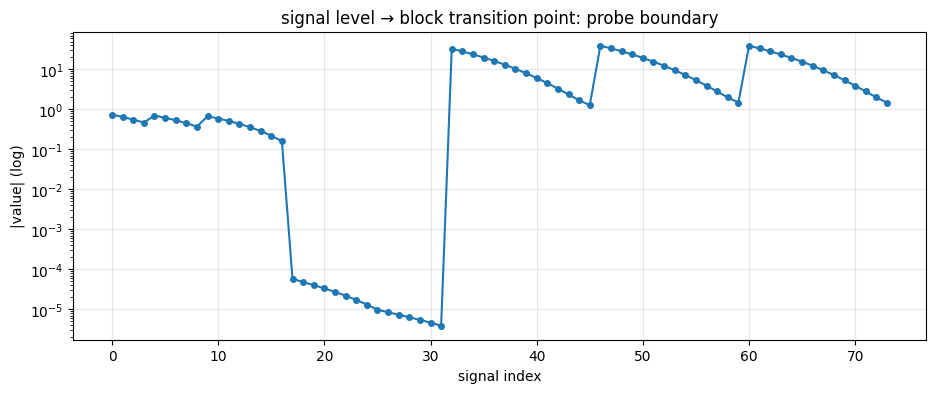

In [6]:
'''
in large scale
ΔΣ ~0.05 - 1 M☉/pc²
wp ~1 - 100 Mpc/h
ξ± ~1e-7 - 1e-4
'''
plt.figure(figsize=(11,4))
plt.semilogy(np.abs(sig), 'o-', ms=4)
plt.xlabel('signal index'); plt.ylabel('|value| (log)')
plt.title('signal level → block transition point: probe boundary')
plt.grid(alpha=.3); plt.savefig('signal_blocks.png', dpi=130)

guess = np.where(np.abs(sig) > 1, 'wp',
         np.where(np.abs(sig) > 1e-2, 'ds', 'xi'))
for p in ['ds','wp','xi']:
    print(f"{p}: {np.sum(guess==p)} points")

'''
1. 分組後 ds=17、wp=42 與 cut 點數吻合
2. 逐點比值(in next cell)在各 block 內連續、光滑、貼近 1 (錯位會產生跳動的無結構比值)
'''

In [7]:
dzph_lit = best[col['dpz_0']] if 'dpz_0' in col else 0.0

cosmo_lit = make_cosmo(omb, omc, 100*h_lit, ns_, s8)
m_mine = theory_vector(cosmo_lit, X=[1,1,1], b=b_lit, A_IA=A_IA_lit, dm=dm_lit, dzph=dzph_lit)    # X=1

lit_wp = sig[-42:]; my_wp = m_mine[-42:]
print(np.round(my_wp/lit_wp, 3))

n_ds_lit = np.sum(guess=='ds'); n_wp_lit = np.sum(guess=='wp')
print(f"reference: ds={n_ds_lit}, wp={n_wp_lit} v.s. mine: ds={n_ds}, wp={n_wp}")
if n_ds_lit == n_ds and n_wp_lit == n_wp:
    sig_ds = sig[guess=='ds']
    sig_wp = sig[guess=='wp']
    my_ds = m_mine[:n_ds]
    my_wp = m_mine[-n_wp:]
    print("ds ratio (mine/lit):", np.round(my_ds/sig_ds, 3))
    print("wp ratio (mine/lit):", np.round(my_wp/sig_wp, 3))
else:
    print("have different number of points → scale cut different (需按 ANG 對位後再比?)")


'''
At the same MAP parameters:

R_fac ≈ 0.979, 0.962, 0.955
E_fac ≈ 1.044, 1.080, 1.094

The signs and redshift trends agree with Eq. (21):
Ω_m > Ω_m,ref gives smaller comoving distances and larger E(z).

wp:
- agrees with the stored MAP signal at the ~0.1% level near the minimum scale cuts
- deviation increases smoothly to ~4% at the largest R
- likely sources include differences in the RSD implementation and the absence of finite-bin averaging
- the present comparison does not isolate these contributions individually

ΔΣ:
- LOWZ agrees at the ~0.3% level
- CMASS1 and CMASS2 are lower by approximately 4% and 7-8%
- the smooth, lens-redshift-dependent offset suggests a lensing-efficiency or redshift-weighting approximation
- likely candidates are the approximate f_ΔΣ weighting, magnification treatment, finite line-of-sight integration, and bin averaging
- this cell alone does not identify which term dominates
'''

R_fac, E_fac in  0 : 0.9787937385975323 1.0440089434955542
R_fac, E_fac in  1 : 0.9617138447051136 1.0801977235015372
R_fac, E_fac in  2 : 0.9549887742448859 1.0941516479251476
[0.999 0.999 0.999 0.999 0.998 0.997 0.995 0.994 0.991 0.988 0.985 0.98
 0.972 0.961 0.999 0.999 0.999 0.998 0.998 0.997 0.995 0.994 0.992 0.989
 0.986 0.982 0.975 0.963 0.999 0.999 0.999 0.999 0.998 0.997 0.996 0.994
 0.992 0.989 0.986 0.982 0.976 0.964]
reference: ds=17, wp=42 v.s. mine: ds=17, wp=42
ds ratio (mine/lit): [1.003 1.003 1.003 1.002 0.963 0.964 0.964 0.963 0.961 0.934 0.936 0.936
 0.934 0.931 0.926 0.919 0.916]
wp ratio (mine/lit): [0.999 0.999 0.999 0.999 0.998 0.997 0.995 0.994 0.991 0.988 0.985 0.98
 0.972 0.961 0.999 0.999 0.999 0.998 0.998 0.997 0.995 0.994 0.992 0.989
 0.986 0.982 0.975 0.963 0.999 0.999 0.999 0.999 0.998 0.997 0.996 0.994
 0.992 0.989 0.986 0.982 0.976 0.964]


'\nAt the same MAP parameters:\n\nR_fac ≈ 0.979, 0.962, 0.955\nE_fac ≈ 1.044, 1.080, 1.094\n\nThe signs and redshift trends agree with Eq. (21):\nΩ_m > Ω_m,ref gives smaller comoving distances and larger E(z).\n\nwp:\n- agrees with the stored MAP signal at the ~0.1% level near the minimum scale cuts\n- deviation increases smoothly to ~4% at the largest R\n- likely sources include differences in the RSD implementation and the absence of finite-bin averaging\n- the present comparison does not isolate these contributions individually\n\nΔΣ:\n- LOWZ agrees at the ~0.3% level\n- CMASS1 and CMASS2 are lower by approximately 4% and 7-8%\n- the smooth, lens-redshift-dependent offset suggests a lensing-efficiency or redshift-weighting approximation\n- likely candidates are the approximate f_ΔΣ weighting, magnification treatment, finite line-of-sight integration, and bin averaging\n- this cell alone does not identify which term dominates\n'

In [8]:
cosmo_planck = make_cosmo(0.02237, 0.1200, 67.36, 0.9649, 0.8111)
cosmo_hscY3 = make_cosmo(omb, omc, h_lit*100, ns_, s8)

b_best = [1.86, 2.10, 2.00]   # 0709 minimize 的 b
b_lit_list = b_lit  # reference b

# theory curve
m_planck = theory_vector(cosmo_planck, X=[1,1,1], b=b_best, A_IA=A_IA_lit, dm=dm_lit, dzph=dzph_lit)
m_lit = theory_vector(cosmo_hscY3,  X=[1,1,1], b=b_lit_list, A_IA=A_IA_lit, dm=dm_lit, dzph=dzph_lit)

chi2_planck = (data_vec - m_planck) @ icov @ (data_vec - m_planck)
chi2_lit = (data_vec - m_lit)    @ icov @ (data_vec - m_lit)
print(f"Planck + X=1 + b: chi2 = {chi2_planck:.1f}")
print(f"ref params + ref b: chi2 = {chi2_lit:.1f}")


'''
The reference MAP parameters give χ² = 73.4 in this pipeline.
The paper reports an observed MAP χ² ≈ 70 and p = 0.43 from 100 noisy-mock analyses.

Thus the difference is only Δχ² ≈ 3.4 relative to the published approximate value,
supporting consistency of the end-to-end pipeline at the statistical precision of the data.
The difference should not be over-interpreted because:
- the published value is rounded
- the MAP estimate from a finite chain is noisy
- the numerical implementation is not identical to the reference code

The Planck value χ² = 194.9 cannot be interpreted as exclusion of Planck:
the adopted b_best values came from an older pipeline and were not re-optimized
with the current theory implementation and nuisance-parameter treatment.
'''

R_fac, E_fac in  0 : 0.993377482652382 1.0135412083291437
R_fac, E_fac in  1 : 0.9877529659657256 1.024971347717655
R_fac, E_fac in  2 : 0.9854668782816985 1.0294477679874368
R_fac, E_fac in  0 : 0.9787937385975323 1.0440089434955542
R_fac, E_fac in  1 : 0.9617138447051136 1.0801977235015372
R_fac, E_fac in  2 : 0.9549887742448859 1.0941516479251476
Planck + X=1 + b: chi2 = 194.9
ref params + ref b: chi2 = 73.4


'\nThe reference MAP parameters give χ² = 73.4 in this pipeline.\nThe paper reports an observed MAP χ² ≈ 70 and p = 0.43 from 100 noisy-mock analyses.\n\nThus the difference is only Δχ² ≈ 3.4 relative to the published approximate value,\nsupporting consistency of the end-to-end pipeline at the statistical precision of the data.\nThe difference should not be over-interpreted because:\n- the published value is rounded\n- the MAP estimate from a finite chain is noisy\n- the numerical implementation is not identical to the reference code\n\nThe Planck value χ² = 194.9 cannot be interpreted as exclusion of Planck:\nthe adopted b_best values came from an older pipeline and were not re-optimized\nwith the current theory implementation and nuisance-parameter treatment.\n'

'\n展示訊號形狀與動態範圍\n(log 軸跨 1-2 decade, 幾 % 的差異不足一個像素)(單純好看用?)\n'

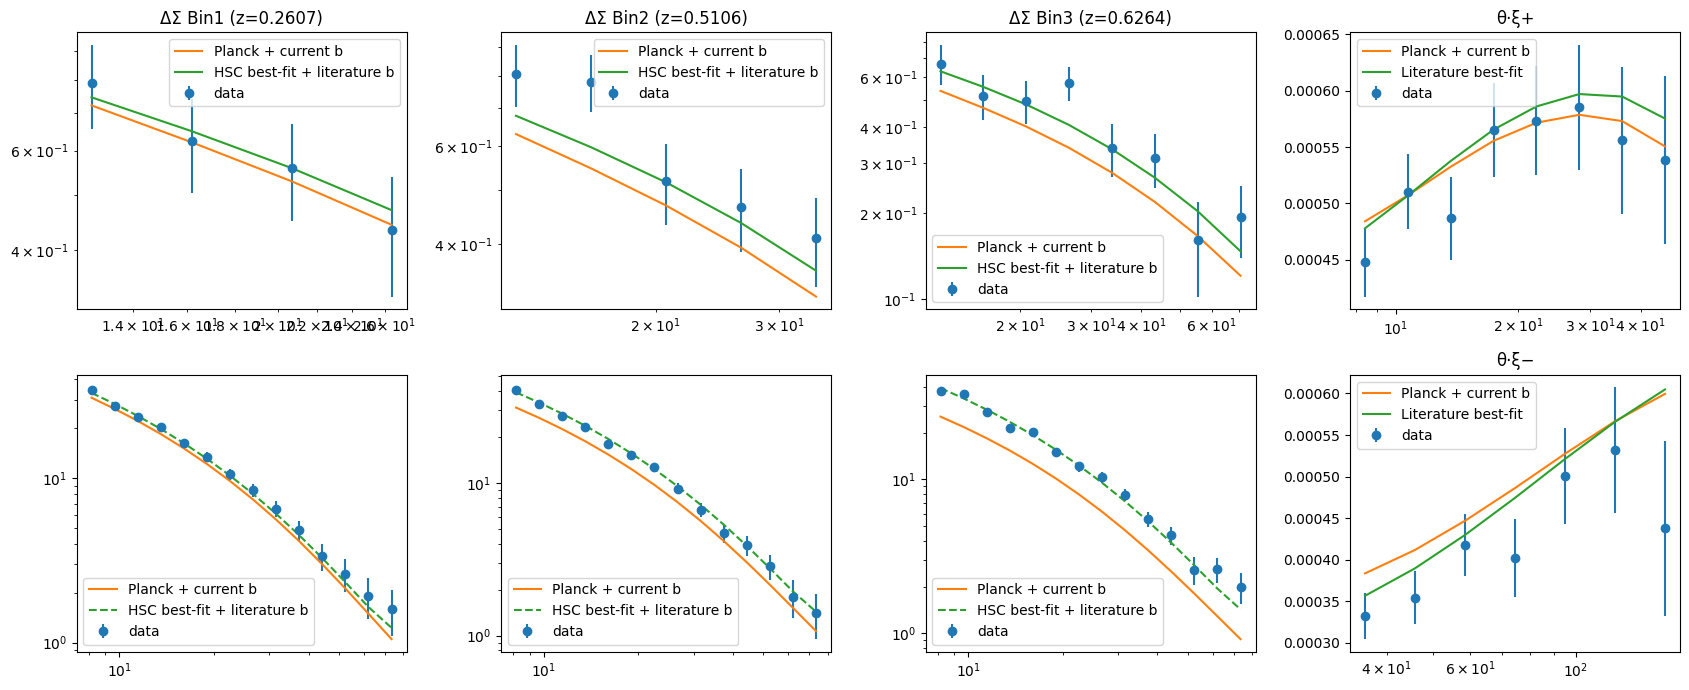

In [9]:
def split(v):
    out, p = {}, 0
    for i in range(3):
        n = ((ds_t['BIN1']==i+1)&ds_cut).sum(); out[f'ds{i+1}'] = v[p:p+n]; p += n
    out['xip'] = v[p:p+n_xip]; p += n_xip
    out['xim'] = v[p:p+n_xim]; p += n_xim
    for i in range(3):
        n = ((wp_t['BIN1']==i+1)&wp_cut).sum(); out[f'wp{i+1}'] = v[p:p+n]; p += n

    return out

D, MP, ML, E = split(data_vec), split(m_planck), split(m_lit),split(err)
fig, ax = plt.subplots(2, 4, figsize=(17, 7))
for i in range(3):
    rp = ds_t['ANG'][(ds_t['BIN1']==i+1)&ds_cut]
    ax[0,i].errorbar(rp, D[f'ds{i+1}'], E[f'ds{i+1}'], fmt='o', label='data')
    ax[0,i].loglog(rp, MP[f'ds{i+1}'], '-', label='Planck + current b')
    ax[0,i].loglog(rp, ML[f'ds{i+1}'], '-', label='HSC best-fit + literature b')
    ax[0,i].set_title(f'ΔΣ Bin{i+1} (z={z_l_eff[i]})')
    ax[0,i].legend()
    
    rw = wp_t['ANG'][(wp_t['BIN1']==i+1)&wp_cut]
    ax[1,i].errorbar(rw, D[f'wp{i+1}'], E[f'wp{i+1}'],fmt='o', label='data')
    ax[1,i].loglog(rw, MP[f'wp{i+1}'], '-',label='Planck + current b')
    ax[1,i].loglog(rw, ML[f'wp{i+1}'], '--',label='HSC best-fit + literature b')
    ax[1, i].legend()

th = xip_t['ANG'][xip_cut]
ax[0,3].errorbar(th, th*D['xip'], th*E['xip'], fmt='o', label='data')
ax[0,3].semilogx(th, th*MP['xip'], '-', label='Planck + current b')
ax[0,3].semilogx(th, th*ML['xip'], '-', label='Literature best-fit')
ax[0,3].set_title('θ·ξ+')
ax[0,3].legend()

th_m = xim_t['ANG'][xim_cut]
ax[1,3].errorbar(th_m, th_m*D['xim'], th_m*E['xim'], fmt='o', label='data')
ax[1,3].semilogx(th_m, th_m*MP['xim'], '-', label='Planck + current b')
ax[1,3].semilogx(th_m, th_m*ML['xim'], '-', label='Literature best-fit')
ax[1,3].set_title('θ·ξ−')
ax[1,3].legend()
plt.tight_layout(); plt.savefig('theory_vs_data.png', dpi=140)

'''
展示訊號形狀與動態範圍
(log 軸跨 1-2 decade, 幾 % 的差異不足一個像素)(單純好看用?)
'''

R_fac, E_fac in  0 : 0.993377482652382 1.0135412083291437
R_fac, E_fac in  1 : 0.9877529659657256 1.024971347717655
R_fac, E_fac in  2 : 0.9854668782816985 1.0294477679874368
R_fac, E_fac in  0 : 0.993377482652382 1.0135412083291437
R_fac, E_fac in  1 : 0.9877529659657256 1.024971347717655
R_fac, E_fac in  2 : 0.9854668782816985 1.0294477679874368
R_fac, E_fac in  0 : 0.993377482652382 1.0135412083291437
R_fac, E_fac in  1 : 0.9877529659657256 1.024971347717655
R_fac, E_fac in  2 : 0.9854668782816985 1.0294477679874368


'\nwp ∝ X², ds ∝ X²\n\n1. 呼叫 theory_vector 時未傳 A_IA/dm/dzph (用了預設 0)\n2. 沿用過期的 b_best: 作為定性示意可接受\n                     BUT 曲線與 cell 8 不在同一模型設定下, so 不可交叉比對數值\n3. X 非 paper 參數\n'

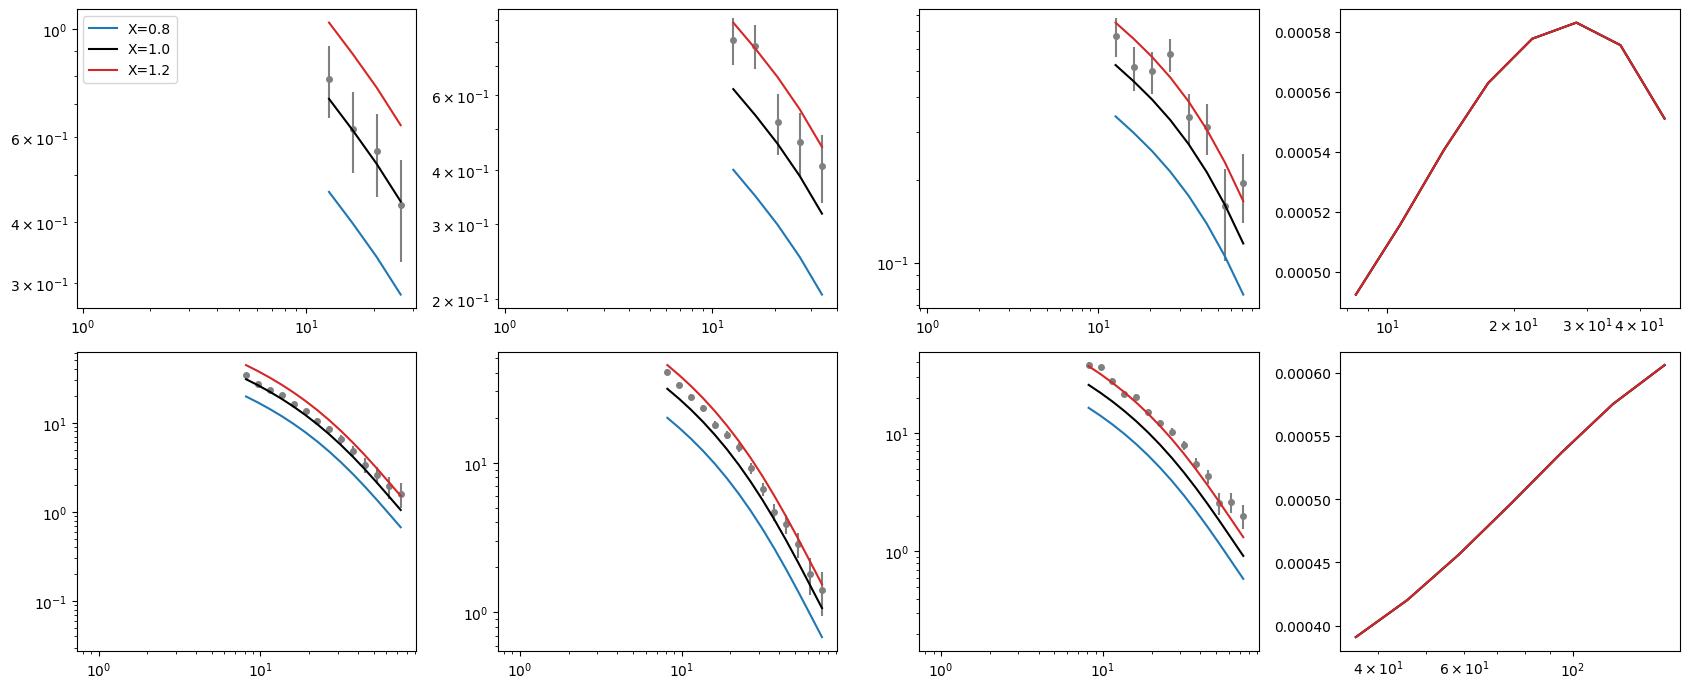

In [10]:
fig, ax = plt.subplots(2, 4, figsize=(17, 7))
for Xv, c in zip([0.8, 1.0, 1.2], ['C0', 'k', 'C3']):
    S = split(theory_vector(cosmo_planck, X=[Xv]*3, b=b_best))
    for i in range(3):
        rp = ds_t['ANG'][(ds_t['BIN1']==i+1)&ds_cut]
        rw = wp_t['ANG'][(wp_t['BIN1']==i+1)&wp_cut]
        ax[0,i].loglog(rp, S[f'ds{i+1}'], c=c, label=f'X={Xv}')
        ax[1,i].loglog(rw, S[f'wp{i+1}'], c=c)
    ax[0,3].semilogx(th, th*S['xip'], c=c)
    ax[1,3].semilogx(th_m, th_m*S['xim'], c=c)

for i in range(3):
    rp = ds_t['ANG'][(ds_t['BIN1']==i+1)&ds_cut]
    rw = wp_t['ANG'][(wp_t['BIN1']==i+1)&wp_cut]
    ax[0,i].errorbar(rp, D[f'ds{i+1}'], E[f'ds{i+1}'], fmt='o', ms=4, c='gray', zorder=0)
    ax[1,i].errorbar(rw, D[f'wp{i+1}'], E[f'wp{i+1}'], fmt='o', ms=4, c='gray', zorder=0)
ax[0,0].legend(); plt.tight_layout(); plt.savefig('X_scan.png', dpi=140)

'''
wp ∝ X², ds ∝ X²

1. 呼叫 theory_vector 時未傳 A_IA/dm/dzph (用了預設 0)
2. 沿用過期的 b_best: 作為定性示意可接受
                     BUT 曲線與 cell 8 不在同一模型設定下, so 不可交叉比對數值
3. X 非 paper 參數
'''

pull: mean=1.64, std=2.09
Planck + current b:
  ds  : sum(pull²) =    28.6  (N=17)
avg of each point:  1.6810480915897714
  xip : sum(pull²) =     3.2  (N=8)
avg of each point:  0.39881852249468225
  xim : sum(pull²) =    13.4  (N=7)
avg of each point:  1.913161026586194
  wp  : sum(pull²) =   475.9  (N=42)
avg of each point:  11.331882170553499
HSC best-fit + literature b:
  ds  : sum(pull²) =    12.9  (N=17)
avg of each point:  0.7585742317124573
  xip : sum(pull²) =     3.7  (N=8)
avg of each point:  0.457294116757433
  xim : sum(pull²) =     7.4  (N=7)
avg of each point:  1.0556927042752648
  wp  : sum(pull²) =    22.7  (N=42)
avg of each point:  0.5410502132659394


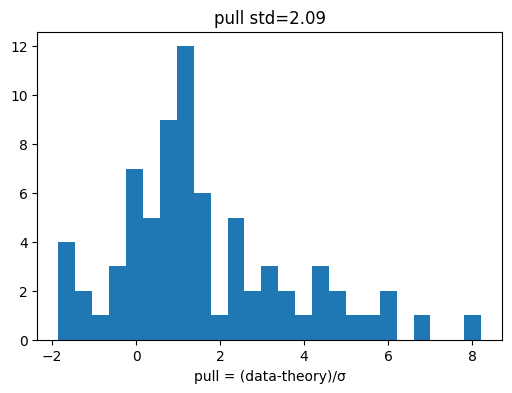

In [11]:
# 對角誤差(each block)統計
# 忽略點間相關

res  = data_vec - m_planck
pull = res / err
print("pull: mean=%.2f, std=%.2f"  % (pull.mean(), pull.std()))

blocks = {'ds': slice(0, n_ds), 'xip': slice(n_ds, n_ds+n_xip),
          'xim': slice(n_ds+n_xip, n_ds+n_xip+n_xim),
          'wp': slice(n_ds+n_xip+n_xim, None)}

plt.figure(figsize=(6,4)); plt.hist(pull, bins=25)
plt.xlabel('pull = (data-theory)/σ'); plt.title(f'pull std={pull.std():.2f}')
plt.savefig('pull_hist.png', dpi=140)

for label, model in [("Planck + current b:", m_planck),("HSC best-fit + literature b:", m_lit)]:
    pull_model = (data_vec - model) / err
    print(label)

    for name, sl in blocks.items():
        print(f"  {name:4s}: sum(pull²) = {np.sum(pull_model[sl]**2):7.1f}  (N={len(pull_model[sl])})")
        print("avg of each point: ", np.sum(pull_model[sl]**2)/len(pull_model[sl]))

'\n!!比值圖測的不是 bias model 的有效性!!\n  mine/lit 比值裡分子分母都是 minimal bias + halofit + Kaiser\n  物理模型的正確性在比值裡完全消掉了 >> 剩數值實作差異\n- RSD 殘餘修正本身隨 R 增大\n- Bin 平均的絕對效應隨 R 增大\n- BAO(?)\n'

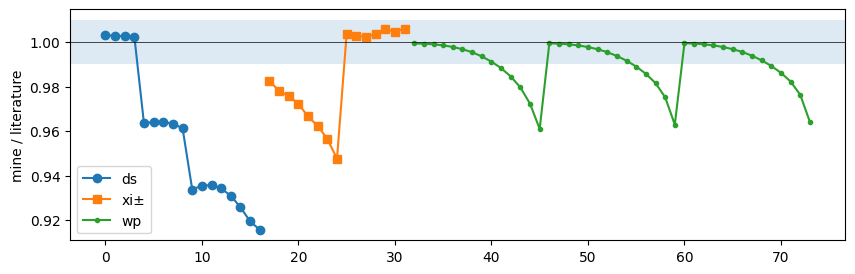

In [12]:
# mine/lit for each block
sig_xi = sig[guess=='xi']
plt.figure(figsize=(10,3))
plt.plot(m_mine[:n_ds]/sig[guess=='ds'], 'o-', label='ds')
plt.plot(np.arange(n_ds, n_ds+15), m_mine[n_ds:n_ds+15]/sig_xi, 's-', label='xi±')
plt.plot(np.arange(n_ds+15, 74), m_mine[-n_wp:]/sig[guess=='wp'], '.-', label='wp')
plt.axhline(1, c='k', lw=.5); plt.axhspan(0.99, 1.01, alpha=.15)
plt.ylabel('mine / literature'); plt.legend()

'''
!!比值圖測的不是 bias model 的有效性!!
  mine/lit 比值裡分子分母都是 minimal bias + halofit + Kaiser
  物理模型的正確性在比值裡完全消掉了 >> 剩數值實作差異
- RSD 殘餘修正本身隨 R 增大
- Bin 平均的絕對效應隨 R 增大
- BAO(?)
'''


'\nDiagnostic only:\n\n- A multiplicative mismatch would approximately follow the ξ+ shape.\n- An additive PSF contribution can have a different scale dependence.\n- The observed discrepancy is of order 10^-6, which is compatible in magnitude\n  with a small PSF additive contribution, but this does not identify it uniquely.\n- The sign of ξ_psf is not guaranteed by α_psf², 2α_psfβ_psf and β_psf² alone,\n  because the measured PSF correlation templates ξpp, ξpq and ξqq can have\n  either sign and nontrivial scale dependence.\n\nA conclusive test requires inserting the measured PSF templates into Eq. (27)\nusing the chain values of α_psf and β_psf.\n'

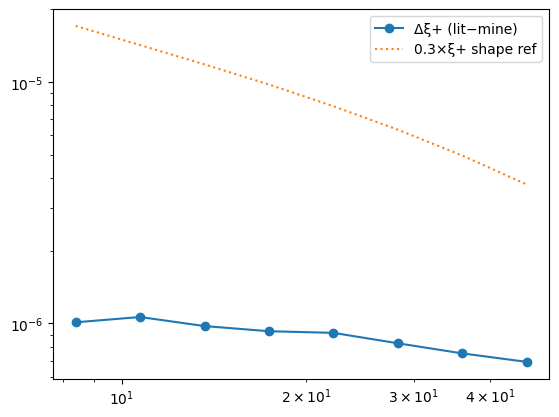

In [13]:
d_xip = sig_xi[:8] - m_mine[n_ds:n_ds+8]     # lit − mine, ξ+
plt.loglog(th, d_xip, 'o-', label='Δξ+ (lit−mine)')
plt.loglog(th, 0.3*m_mine[n_ds:n_ds+8], ':', label='0.3×ξ+ shape ref')
plt.legend()

'''
Diagnostic only:

- A multiplicative mismatch would approximately follow the ξ+ shape.
- An additive PSF contribution can have a different scale dependence.
- The observed discrepancy is of order 10^-6, which is compatible in magnitude
  with a small PSF additive contribution, but this does not identify it uniquely.
- The sign of ξ_psf is not guaranteed by α_psf², 2α_psfβ_psf and β_psf² alone,
  because the measured PSF correlation templates ξpp, ξpq and ξqq can have
  either sign and nontrivial scale dependence.

A conclusive test requires inserting the measured PSF templates into Eq. (27)
using the chain values of α_psf and β_psf.
'''

In [14]:
cosmo_map = make_cosmo(
    ombh2=0.023018656,
    omch2=0.11748303,
    H0=69.551912,
    ns=0.95940748,
    sigma8=0.78272345
)

m_map = theory_vector(
    cosmo_map,
    X=[1.0584525, 1.1665719, 1.2463822],
    b=[1.8552724, 2.0503362, 1.9956013],
    A_IA=-0.79407104,
    dm=0.0011879888,
    dzph=-0.029562746
)

print("theory-vector length =", len(m_map))

R_fac, E_fac in  0 : 0.9978006736999703 1.0044770157552838
R_fac, E_fac in  1 : 0.9959017610225543 1.0082871807314173
R_fac, E_fac in  2 : 0.9951219472402375 1.0097870538619904
theory-vector length = 74


In [15]:
diff_map = data_vec - m_map
chi2_map = diff_map @ icov @ diff_map
pull_map = diff_map / err

print("notebook 重算 chi2 =", chi2_map)
print("minimum 檔案 chi2 =", 71.332293)
print("pull length =", len(pull_map))

notebook 重算 chi2 = 71.33229818700394
minimum 檔案 chi2 = 71.332293
pull length = 74


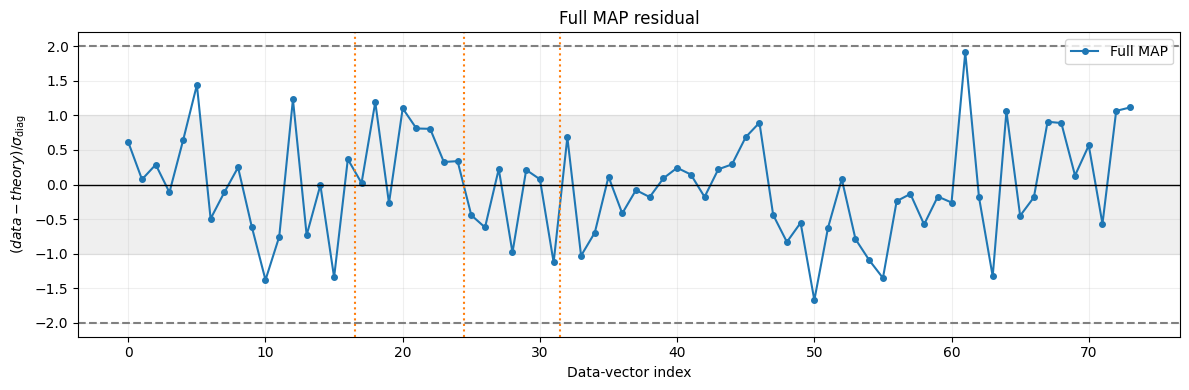

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(pull_map, "o-", ms=4, label="Full MAP")

plt.axhspan(-1, 1, color="gray", alpha=0.12)
plt.axhline(0, color="black", lw=1)
plt.axhline(2, color="gray", ls="--")
plt.axhline(-2, color="gray", ls="--")

# ΔΣ | ξ+ | ξ− | wp 的分界
plt.axvline(n_ds - 0.5, color="C1", ls=":")
plt.axvline(n_ds + n_xip - 0.5, color="C1", ls=":")
plt.axvline(n_ds + n_xip + n_xim - 0.5, color="C1", ls=":")

plt.xlabel("Data-vector index")
plt.ylabel(r"$(data-theory)/\sigma_{\rm diag}$")
plt.title("Full MAP residual")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [17]:
cosmo_noAIA = make_cosmo(
    ombh2=0.022754515,
    omch2=0.11693655,
    H0=68.852195,
    ns=0.96960122,
    sigma8=0.78530613
)

m_noAIA = theory_vector(
    cosmo_noAIA,
    X=[1.0609352, 1.1696204, 1.2531561],
    b=[1.8570786, 2.0541879, 1.9919963],
    A_IA=0.0,
    dm=0.00052179136,
    dzph=-0.030099128
)

diff_noAIA = data_vec - m_noAIA
pull_noAIA = diff_noAIA / err
chi2_noAIA = diff_noAIA @ icov @ diff_noAIA

print("notebook 重算 no-AIA chi2 =", chi2_noAIA)
print("minimum 檔案 no-AIA chi2 =", 71.383701)

R_fac, E_fac in  0 : 0.9969939733011731 1.006124126042935
R_fac, E_fac in  1 : 0.9944063712232025 1.0113282257715461
R_fac, E_fac in  2 : 0.9933457613614347 1.013374870840504
notebook 重算 no-AIA chi2 = 71.38371928288078
minimum 檔案 no-AIA chi2 = 71.383701


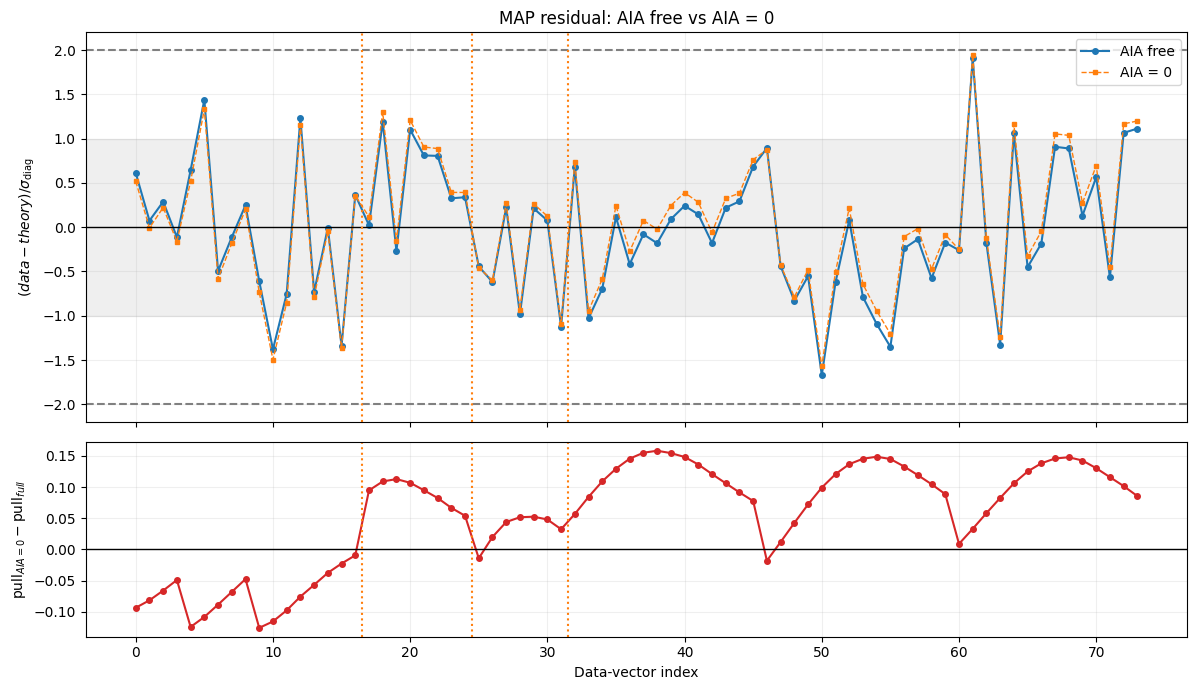

In [18]:
fig, ax = plt.subplots(
    2, 1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# 上圖：兩組 MAP residual
ax[0].plot(
    pull_map, "o-",
    ms=4, lw=1.5,
    label="AIA free"
)
ax[0].plot(
    pull_noAIA, "s--",
    ms=3.5, lw=1.0,
    label="AIA = 0"
)

ax[0].axhspan(-1, 1, color="gray", alpha=0.12)
ax[0].axhline(0, color="black", lw=1)
ax[0].axhline(2, color="gray", ls="--")
ax[0].axhline(-2, color="gray", ls="--")
ax[0].set_ylabel(r"$(data-theory)/\sigma_{\rm diag}$")
ax[0].set_title("MAP residual: AIA free vs AIA = 0")
ax[0].legend()
ax[0].grid(alpha=0.2)

# 下圖：no-AIA residual 相對 full residual 的變化
delta_pull_AIA = pull_noAIA - pull_map

ax[1].plot(
    delta_pull_AIA, "o-",
    color="C3", ms=4
)
ax[1].axhline(0, color="black", lw=1)
ax[1].set_xlabel("Data-vector index")
ax[1].set_ylabel(
    r"${\rm pull}_{AIA=0}-{\rm pull}_{full}$"
)
ax[1].grid(alpha=0.2)

# observable 分界
for a in ax:
    a.axvline(n_ds - 0.5, color="C1", ls=":")
    a.axvline(n_ds + n_xip - 0.5, color="C1", ls=":")
    a.axvline(
        n_ds + n_xip + n_xim - 0.5,
        color="C1", ls=":"
    )

plt.tight_layout()
plt.show()

In [ ]:
# χ²、S8、Xi comparison table

from pathlib import Path
import pandas as pd
import numpy as np

def read_minimum(filename):
    filename = Path(filename)
    with open(filename, "r") as f:
        column_names = f.readline().lstrip("#").split()

    table = pd.read_csv(
        filename,
        sep=r"\s+",
        comment="#",
        names=column_names
    )
    return table.iloc[0]

In [25]:
minimum_files = {
    "full": "/home/weichen/cosmo_practice/chains/chains_kawas/0721_hsc_lens_only_study_minimize.minimum.txt",
    "no_AIA": "/home/weichen/cosmo_practice/chains/chains_kawas/noAIA_hsc_lens_only_study_minimize.minimum.txt",
    "no_dm0": "/home/weichen/cosmo_practice/chains/chains_kawas/nodm0_hsc_lens_only_study_minimize.minimum.txt",
    "fixed_dpz": "/home/weichen/cosmo_practice/chains/chains_kawas/nodpz_hsc_lens_only_study_minimize.minimum.txt",
    "all_fixed": "/home/weichen/cosmo_practice/chains/chains_kawas/hsc_only_allfix_minimize.minimum.txt",
}

minimum_results = {
    name: read_minimum(filename)
    for name, filename in minimum_files.items()
}

In [ ]:
rows = {}
for name, result in minimum_results.items():
    rows[name] = {
        "chi2": result["chi2"],
        "om_m": result["om_m"],
        "sigma8": result["sigma8"],
        "X1": result["X1"],
        "X2": result["X2"],
        "X3": result["X3"],
    }

comparison = pd.DataFrame(rows).T
comparison["S8"] = (comparison["sigma8"] * np.sqrt(comparison["om_m"] / 0.3))

# 相對於 full MAP
comparison["delta_chi2"] = (comparison["chi2"] - comparison.loc["full", "chi2"])
comparison["delta_S8"] = (comparison["S8"] - comparison.loc["full", "S8"])
comparison = comparison[
    [
        "chi2",
        "delta_chi2",
        "om_m",
        "sigma8",
        "S8",
        "delta_S8",
        "X1",
        "X2",
        "X3",
    ]
]
display(comparison.round(4))

,chi2,delta_chi2,om_m,sigma8,S8,delta_S8,X1,X2,X3
full,71.3323,0.0000,0.2904,0.7827,0.7702,0.0000,1.0585,1.1666,1.2464
no_AIA,71.3837,0.0514,0.2947,0.7853,0.7783,0.0081,1.0609,1.1696,1.2532
no_dm0,71.3962,0.0639,0.2926,0.7849,0.7752,0.0050,1.0606,1.1651,1.2507
fixed_dpz,71.1545,-0.1778,0.2944,0.7851,0.7778,0.0076,1.0615,1.1780,1.2488
all_fixed,70.8240,-0.5083,0.3117,0.7799,0.7950,0.0248,1.0578,1.1718,1.2492
